In [ ]:
import numpy as np
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

R=10.0          # Radius Pec
N_S=64          # spatial nodes
N_T=256         # temporal nodes
N_G=8           # amount of weights for quadrature
c=3e8           # light constant
mu=np.pi * 4e-7 # permeability
dt = 1e-8       # timestep

In [3]:
xy = np.arange(2)      # coordinates
m = np.arange(N_S + 1) # spatial steps

#                                 xy m
u_x = np.asarray([1, 0]).reshape((-1,1))
u_y = np.asarray([0, 1]).reshape((-1,1))

In [4]:
x, w = np.polynomial.legendre.leggauss(N_G)
x, w = (x + 1)/2, w/2

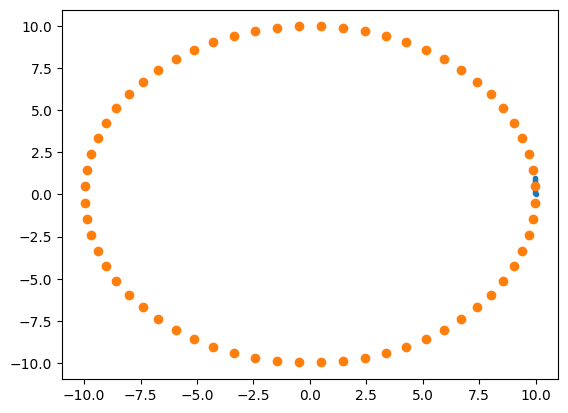

In [ ]:
# [m] (xy,N_S+1) discretisation points of curve
curve = R*(np.cos(2*np.pi*m/N_S)*u_x + np.sin(2*np.pi*m/N_S)*u_y)

# [m] (xy, N_S) centers of N_S segments
rho = (curve[xy, 1:] + curve[xy, :-1])/2

# [m] (xy,N_S) tangent vectors
tangents = curve[xy, 1:] - curve[xy, :-1]

# [m] (N_S) lengths of segments
l = np.linalg.vector_norm(tangents, axis=0)
L = np.minimum(l, 2*c*dt)

# [m] (xy, N_S, N_G) g coordinates along m segments
rhop = curve[xy, :-1].reshape((2,N_S,1)) + x*tangents[xy, :].reshape((2,N_S,1))

plt.plot(rhop[0,0,:], rhop[1,0,:], '.')
plt.plot(rho[xy[0],:], rho[xy[1],:], 'o')
plt.show()

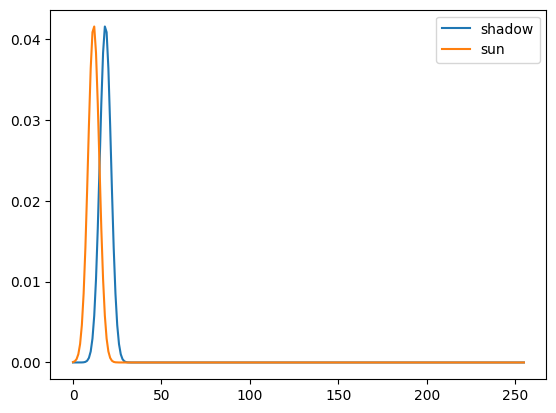

In [26]:
t_0 = 1.5e-7 # [s] center of pulse
T = 54       # [m] width of pulse
def E_i(rho, t):
    gamma = 4 / T * (c * (t - t_0) - rho[xy[0]])
    return 4 / T / np.sqrt(np.pi) * np.exp(-gamma**2) 

j = np.arange(N_T).reshape((-1,1))
# (j,m)
V = E_i(rho, j*dt)

plt.plot(V[:,0],      label="shadow")
plt.plot(V[:,N_S//2], label="sun")
plt.legend()
plt.show()

In [7]:
#                         xy m  n    g
rho_resh  = rho .reshape((2,-1, 1,   1  ))
rhop_resh = rhop.reshape((2, 1, N_S, N_G))
# (m,n,g)
dist_c = (np.linalg.vector_norm(rho_resh - rhop_resh, axis=0)/c)
#                            k  m  n  g
k = np.arange(N_T).reshape((-1, 1, 1, 1))
# (k,m,n,g)
a = np.maximum(k*dt, dist_c)
b = np.maximum((k+1)*dt, dist_c)
# (k,m,n,g)
F = np.log((b + np.sqrt(b**2 - dist_c**2))/(a + np.sqrt(a**2 - dist_c**2)))

n = np.arange(N_S).reshape((1,1,-1))
# (k,m,n)
Z = -l[n]/2/np.pi * np.einsum('g,kmng->kmn', w, F)
for m in range(N_S):
    root = np.sqrt((2*c*dt)**2 - L[m]**2)
    Z[0,m,m] = -L[m]/2/np.pi * np.log((2*c*dt + root)/L[m]) - c*dt/np.pi * np.arctan(L[m]/root)

# (i,n)
U = np.zeros((N_T, N_S))

U[0,:], info = spla.gmres(A=Z[0,:,:], b=-V[0,:])
assert info == 0

for j in range(1, N_T):
    k = np.arange(j)
    i = j - k
    U[j,:], info = spla.gmres(A=Z[0,:,:], b= -V[j,:] - np.einsum(f'kmn,km->n', Z[k,:,:], U[i,:]))
    assert info == 0

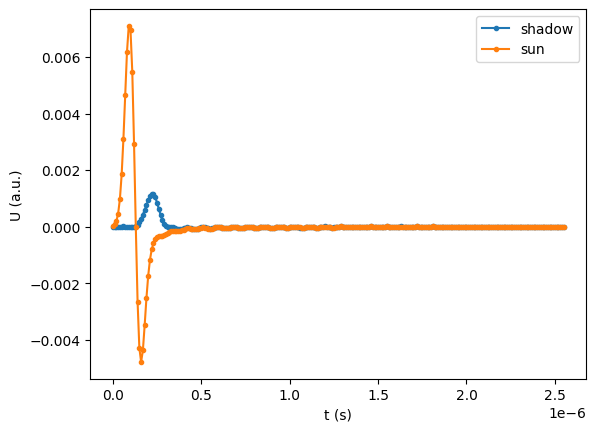

In [22]:
t = dt*np.arange(N_T)

plt.plot(t, U[:,0], '.-', label="shadow")
plt.plot(t, U[:,N_S//2], '.-', label="sun")
plt.xlabel("t (s)")
plt.ylabel("U (a.u.)")
plt.legend()
plt.show()

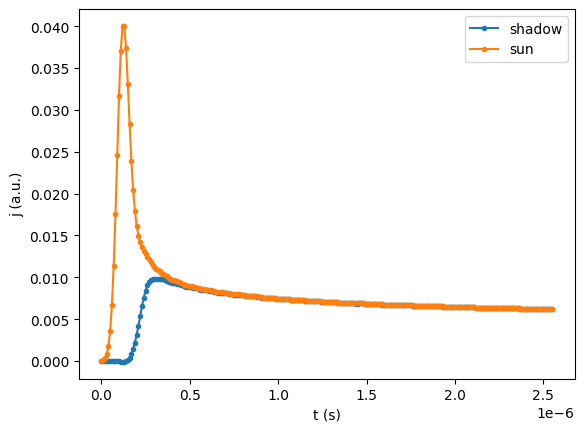

In [23]:
j = np.cumsum(U, axis=0)

plt.plot(t, j[:,0], '.-', label="shadow")
plt.plot(t, j[:,N_S//2], '.-', label="sun")
plt.xlabel("t (s)")
plt.ylabel("j (a.u.)")
plt.legend()
plt.show()

(129,)


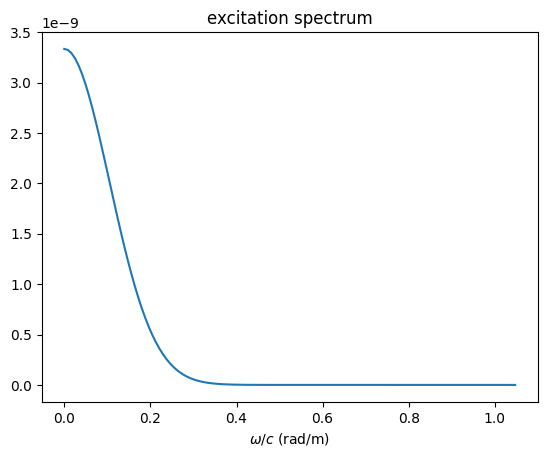

C:\Users\joran\AppData\Local\Temp\ipykernel_1668\2586921340.py:15: RuntimeWarning: divide by zero encountered in divide
  j0 = (-1j/omega/A/mu).reshape((-1,1))*u
C:\Users\joran\AppData\Local\Temp\ipykernel_1668\2586921340.py:15: RuntimeWarning: invalid value encountered in divide
  j0 = (-1j/omega/A/mu).reshape((-1,1))*u


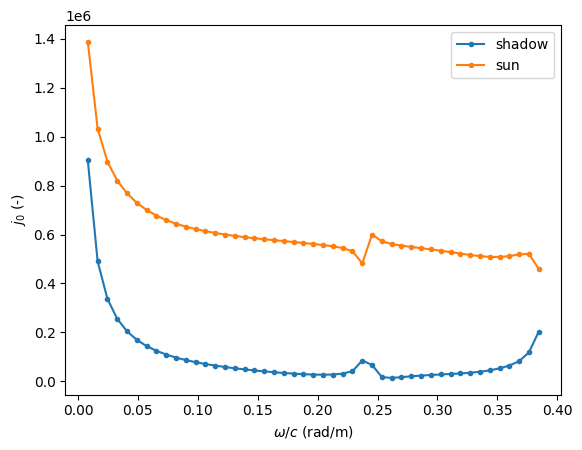

In [13]:
u = np.fft.rfft(U, axis=0)
omega = 2*np.pi * np.fft.rfftfreq(N_T, dt)

# excitation spectrum
A = np.exp(-1j * omega * t_0 - (T * omega / (8 * c))**2) / c

mask = np.abs(A) > 1e-3 * np.max(np.abs(A))
print(mask.shape)

plt.plot(omega/c, np.abs(A))
plt.xlabel("$\\omega / c$ (rad/m)")
plt.title("excitation spectrum")
plt.show()

j0 = (-1j/omega/A/mu).reshape((-1,1))*u

plt.plot(omega[mask]/c, np.abs(j0[mask,0]), '.-', label="shadow")
plt.plot(omega[mask]/c, np.abs(j0[mask,N_S//2]), '.-', label="sun")
plt.xlabel("$\\omega / c$ (rad/m)")
plt.ylabel("$j_0$ (-)")
plt.legend()
plt.show()

C:\Users\joran\AppData\Roaming\Python\Python313\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\joran\AppData\Roaming\Python\Python313\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


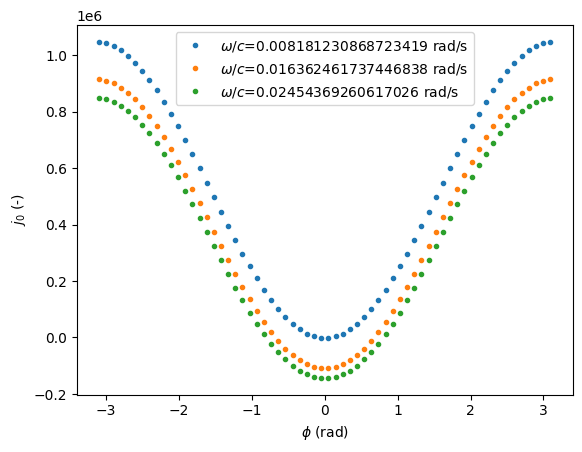

In [12]:
plt.plot(np.arctan2(rho[xy[1],:], rho[xy[0],:]), j0[1,:], '.', label=f"$\\omega/c$={omega[1]/c} rad/s")
plt.plot(np.arctan2(rho[xy[1],:], rho[xy[0],:]), j0[2,:], '.', label=f"$\\omega/c$={omega[2]/c} rad/s")
plt.plot(np.arctan2(rho[xy[1],:], rho[xy[0],:]), j0[3,:], '.', label=f"$\\omega/c$={omega[3]/c} rad/s")
plt.xlabel("$\\phi$ (rad)")
plt.ylabel("$j_0$ (-)")
plt.legend()
plt.show()